# Rozpoznawanie symboli nutowych - Deep Learning (multi-head CNN)

## Architektura

Jeden model CNN z **dwoma glowicami** trenowanymi jednoczesnie:

| Glowica | Zadanie | Wejscie | Uwagi |
|---|---|---|---|
| `head_type` | Typ symbolu (note4, sharp, clef_treble...) | obraz **bez** linii pieciolinii | ~20 klas |
| `head_pos` | Wysokosc dzwieku (`rel_position`) | obraz **z** liniami | tylko dla nut i znakow chr. |

Model przyjmuje **2-kanalowy tensor**:
- kanal 0: oryginalny obraz (z pieciolinia) -> informacja o pozycji
- kanal 1: obraz po usunieciu pieciolinii -> informacja o ksztalcie symbolu

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import time
import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Compatibility shim: some older checkpoints expect torch.utils.serialization
try:
    if not hasattr(torch.utils, 'serialization'):
        torch.utils.serialization = torch.serialization
except Exception:
    pass

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

BASE        = Path('../data/note_dataset')
NOTES_DIR   = BASE / 'notes'
SYMBOLS_DIR = BASE / 'symbols'
TENSORS_DIR = BASE / 'tensors'
IMG_W, IMG_H = 32, 96
NO_POS_LABEL = -1

Device: cpu


## Preprocessing: binaryzacja i usuwanie pieciolinii

..\data\note_dataset\notes
10000


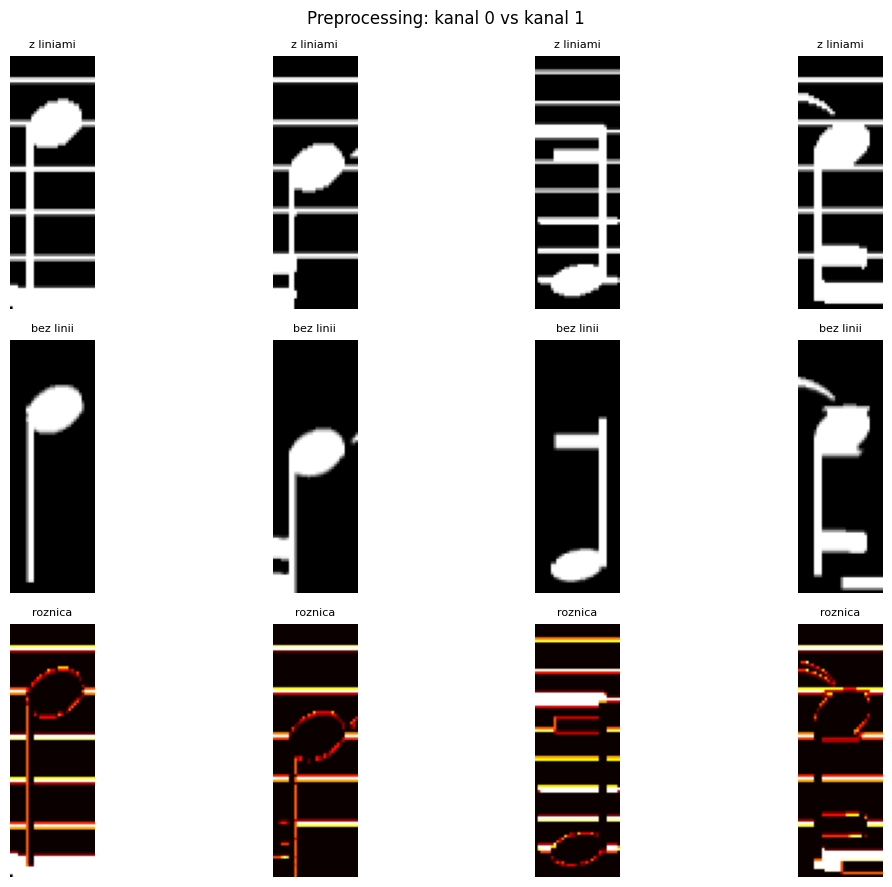

In [2]:
def to_white_on_black(gray):
    corners = [gray[0,0], gray[0,-1], gray[-1,0], gray[-1,-1]]
    if int(np.median(corners)) > 127:
        return cv2.bitwise_not(gray)
    return gray.copy()


def remove_staff_lines(img_wob, scale=2, fill_thresh=0.80):
    h, w = img_wob.shape
    big = cv2.resize(img_wob, (w*scale, h*scale), interpolation=cv2.INTER_CUBIC)
    _, binary = cv2.threshold(big, 127, 255, cv2.THRESH_BINARY)
    H, W = binary.shape

    profile = binary.sum(axis=1) / (W * 255)
    line_rows = set()
    for y, fill in enumerate(profile):
        if fill >= fill_thresh:
            for d in range(-scale, scale+1):
                if 0 <= y+d < H:
                    line_rows.add(y+d)

    result = binary.copy()
    search = scale * 4
    for y in sorted(line_rows):
        for x in range(W):
            if binary[y, x] == 0:
                continue
            has_symbol = any(
                binary[y2, x] > 0
                for r in range(1, search+1)
                for y2 in [y-r, y+r]
                if 0 <= y2 < H and y2 not in line_rows
            )
            if not has_symbol:
                result[y, x] = 0

    n_lbl, labels, stats, _ = cv2.connectedComponentsWithStats(result)
    clean = np.zeros_like(result)
    for lbl in range(1, n_lbl):
        if stats[lbl, cv2.CC_STAT_AREA] >= scale*scale*4:
            clean[labels == lbl] = 255

    k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(3, scale*2)))
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k)
    return cv2.resize(clean, (w, h), interpolation=cv2.INTER_AREA)


def preprocess(img_path):
    """Zwraca tensor (2, H, W): kanal 0 = z liniami, kanal 1 = bez linii."""
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        return np.zeros((2, IMG_H, IMG_W), dtype=np.float32)
    wob   = to_white_on_black(gray)
    _, orig_bin = cv2.threshold(wob, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    clean = remove_staff_lines(wob)
    orig  = cv2.resize(orig_bin, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    cln   = cv2.resize(clean,    (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    return np.stack([orig, cln], axis=0)


# Podglad
print(NOTES_DIR)
paths = list((NOTES_DIR / 'images').glob('*.png'))
print(len(paths))

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for col, p in enumerate(sorted((NOTES_DIR/'images').glob('*.png'))[:4]):
    t = preprocess(p)
    axes[0,col].imshow(t[0], cmap='gray'); axes[0,col].set_title('z liniami',  fontsize=8); axes[0,col].axis('off')
    axes[1,col].imshow(t[1], cmap='gray'); axes[1,col].set_title('bez linii',  fontsize=8); axes[1,col].axis('off')
    axes[2,col].imshow(np.abs(t[0]-t[1]), cmap='hot'); axes[2,col].set_title('roznica', fontsize=8); axes[2,col].axis('off')
plt.suptitle('Preprocessing: kanal 0 vs kanal 1'); plt.tight_layout(); plt.show()

## Dataset i etykiety

In [3]:
df_notes   = pd.read_csv(NOTES_DIR   / 'labels.csv')
df_symbols = pd.read_csv(SYMBOLS_DIR / 'labels.csv')
df_notes['img_dir']   = str(NOTES_DIR   / 'images')
df_notes['symbol']    = df_notes['note_type']
df_symbols['img_dir'] = str(SYMBOLS_DIR / 'images')

df = pd.concat([
    df_notes  [['id','symbol','rel_position', 'duration','img_dir']],
    df_symbols[['id','symbol','rel_position','img_dir']],
], ignore_index=True)

df = df[df['rel_position'].isna() | df['rel_position'].between(-20, 20)]

TYPE_CLASSES = sorted(df['symbol'].unique())
type2idx     = {c: i for i, c in enumerate(TYPE_CLASSES)}
NUM_TYPES    = len(TYPE_CLASSES)

HAS_POSITION = {'note1','note2','note4','note8','note16',
                'sharp','flat','natural','double_sharp','double_flat'}
POS_MASK     = df['symbol'].isin(HAS_POSITION) & df['rel_position'].notna()
valid_pos    = sorted(df.loc[POS_MASK, 'rel_position'].dropna().unique().astype(int))
pos2idx      = {p: i for i, p in enumerate(valid_pos)}
NUM_POS      = len(valid_pos)

df['type_label'] = df['symbol'].map(type2idx)
df['pos_label']  = df.apply(
    lambda r: pos2idx[int(r['rel_position'])]
    if r['symbol'] in HAS_POSITION and pd.notna(r['rel_position'])
    and int(r['rel_position']) in pos2idx
    else NO_POS_LABEL, axis=1)

print(f'Lacznie: {len(df)} przykladow')
print(f'Typy ({NUM_TYPES}): {TYPE_CLASSES}')
print(f'Pozycje ({NUM_POS}): {valid_pos[0]} .. {valid_pos[-1]}')
print()
print(df['symbol'].value_counts().to_string())

Lacznie: 19998 przykladow
Typy (33): ['clef_8', 'clef_alto', 'clef_bass', 'clef_tenor', 'clef_treble', 'dot', 'double_sharp', 'flat', 'natural', 'note1', 'note16', 'note2', 'note4', 'note8', 'rest_16th', 'rest_32nd', 'rest_8th', 'rest_half', 'rest_quarter', 'rest_whole', 'sharp', 'time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6', 'time_7', 'time_8', 'time_9', 'time_common', 'time_cut']
Pozycje (34): -15 .. 19

symbol
note4           7415
dot             1629
rest_whole      1266
rest_8th        1053
clef_treble      977
sharp            924
note8            894
note16           795
rest_quarter     731
clef_bass        646
note2            638
natural          638
flat             532
time_4           321
rest_half        296
note1            258
rest_16th        191
time_8           150
clef_8           141
clef_alto        109
time_7            94
clef_tenor        61
time_3            53
time_2            30
time_1            29
time_6            24
time_cut      

In [4]:
# Sprawdź unikalne wartości duration w notach
print(df_notes['duration'].value_counts().head(20))

duration
8         3971
16        2287
4         2031
2          573
32         304
1          254
4.         176
8.         156
2.         110
8*2/3       69
16.         33
2*1/2       12
4*2/3       12
2..          6
16*2/3       3
1.           3
Name: count, dtype: int64


In [5]:
def simplify_duration(dur):
    """Sprowadź złożone wartości do podstawowej wartości rytmicznej."""
    if pd.isna(dur) or str(dur).strip() == '':
        return 'unknown'
    s = str(dur).strip()
    
    import re
    m = re.match(r'^(\d+)', s)
    if not m:
        return 'other'
    base = int(m.group(1))
    if   base == 1:   return 'whole'
    elif base == 2:   return 'half'
    elif base == 4:   return 'quarter'
    elif base == 8:   return 'eighth'
    elif base == 16:  return 'sixteenth'
    elif base == 32:  return 'thirty_second'
    elif base >= 64:  return 'other'
    return 'other'

df['duration_simple'] = df.apply(
    lambda r: simplify_duration(r.get('duration'))
    if 'note' in str(r['symbol']) else 'no_duration',
    axis=1
)

DUR_CLASSES  = sorted(df['duration_simple'].unique())
dur2idx      = {c: i for i, c in enumerate(DUR_CLASSES)}
NUM_DUR      = len(DUR_CLASSES)
NO_DUR_LABEL = dur2idx['no_duration']

df['dur_label'] = df['duration_simple'].map(dur2idx)
print(f'Klasy duration ({NUM_DUR}): {DUR_CLASSES}')
print(df['duration_simple'].unique())


Klasy duration (7): ['eighth', 'half', 'no_duration', 'quarter', 'sixteenth', 'thirty_second', 'whole']
<StringArray>
[       'eighth',     'sixteenth',       'quarter',          'half',
         'whole', 'thirty_second',   'no_duration']
Length: 7, dtype: str


In [6]:
def precompute_all(df, out_dir, force=False):
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)

    skipped = 0
    for _, row in tqdm(df.iterrows(), total=len(df)):
        src  = Path(row['img_dir']) / row['id']

        # Unikalny klucz: notes_000000.npy lub symbols_000000.npy
        source = 'notes' if 'notes' in row['img_dir'] else 'symbols'
        dest   = out_dir / f"{source}_{row['id'].replace('.png', '.npy')}"

        if dest.exists() and not force:
            skipped += 1
            continue

        tensor = preprocess(src)
        np.save(dest, tensor)

    print(f'Gotowe. Pominięto: {skipped}')


precompute_all(df, '../data/note_dataset/tensors')

100%|██████████| 19998/19998 [00:01<00:00, 17389.50it/s]

Gotowe. Pominięto: 19998


In [7]:
class MusicDataset(Dataset):
    def __init__(self, df, tensor_dir, augment=False):
        self.df         = df.reset_index(drop=True)
        self.tensor_dir = Path(tensor_dir)
        self.augment    = augment
    
    def __len__(self):     
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        source = 'notes' if 'notes' in row['img_dir'] else 'symbols'
        npy    = self.tensor_dir / f"{source}_{row['id'].replace('.png', '.npy')}"
        tensor = np.load(str(npy))

        if self.augment and np.random.rand() < 0.3:
            tensor = tensor[:, :, ::-1].copy()
        if self.augment and np.random.rand() < 0.3:
            tensor = np.clip(tensor + np.random.randn(*tensor.shape).astype(np.float32)*0.03, 0, 1)

        return (torch.tensor(tensor, dtype=torch.float32),
                torch.tensor(int(row['type_label']), dtype=torch.long),
                torch.tensor(int(row['pos_label']),  dtype=torch.long),
                torch.tensor(int(row['dur_label']),  dtype=torch.long))


# Create a held-out test set for unbiased evaluation (10%), then train/val split on remaining
type_counts = df['type_label'].value_counts()
can_stratify = type_counts.min() >= 2
if not can_stratify:
    rare_labels = type_counts[type_counts < 2].index.tolist()
    print(f'Warning: rare classes with <2 samples found: {rare_labels}. Falling back to non-stratified split.')

split_kwargs = dict(test_size=0.1, random_state=42)
if can_stratify:
    split_kwargs['stratify'] = df['type_label']
df_trainval, df_test = train_test_split(df, **split_kwargs)

trainval_counts = df_trainval['type_label'].value_counts()
can_stratify_tv = trainval_counts.min() >= 2
split_tv_kwargs = dict(test_size=0.2, random_state=42)
if can_stratify_tv:
    split_tv_kwargs['stratify'] = df_trainval['type_label']
df_train, df_val = train_test_split(df_trainval, **split_tv_kwargs)

train_ds = MusicDataset(df_train, TENSORS_DIR, augment=True)
val_ds   = MusicDataset(df_val,   TENSORS_DIR, augment=False)
test_ds  = MusicDataset(df_test,  TENSORS_DIR, augment=False)

counts  = df_train['type_label'].value_counts()
weights = df_train['type_label'].map(lambda l: 1.0 / counts[l]).values
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,    num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False,    num_workers=0, pin_memory=True)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

Train: 14398  Val: 3600  Test: 2000


C:\Users\bielo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\sampler.py:228: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  weights_tensor = torch.as_tensor(weights, dtype=torch.double)


## Architektura modelu

In [8]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x): return self.relu(x + self.block(x))


class MusicCNN(nn.Module):
    """
    Wejscie: (B, 2, 96, 32)
      kanal 0 = z liniami  -> pozycja na pieciolinii
      kanal 1 = bez linii  -> ksztalt symbolu

    Backbone wspolny, dwie glowice:
      head_type -> typ symbolu (20 klas)
      head_pos  -> rel_position (34 klasy, tylko nuty i accidentals)
      head_dur  -> duration (10 klas)
    """
    def __init__(self, num_types, num_pos, num_dur):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            ResBlock(32), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResBlock(64), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            ResBlock(128), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 2)),
        )
        feat = 256 * 4 * 2

        self.head_type = nn.Sequential(
            nn.Flatten(), nn.Linear(feat, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(256, num_types))

        self.head_pos = nn.Sequential(
            nn.Flatten(), nn.Linear(feat, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(256, num_pos))
        
        self.head_dur = nn.Sequential(        
            nn.Flatten(), nn.Linear(feat, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_dur))

    def forward(self, x):
        f = self.backbone(x)
        return self.head_type(f), self.head_pos(f), self.head_dur(f)


model = MusicCNN(NUM_TYPES, NUM_POS, NUM_DUR).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Parametry: {total:,}')
x_test = torch.randn(4, 2, IMG_H, IMG_W).to(DEVICE)
t_out, p_out, d_out = model(x_test)
print(f'Wyjscie type: {t_out.shape}  pos: {p_out.shape}  dur: {d_out.shape}')

Parametry: 2,106,058
Wyjscie type: torch.Size([4, 33])  pos: torch.Size([4, 34])  dur: torch.Size([4, 7])


## Trening

In [9]:
criterion_type = nn.CrossEntropyLoss()
criterion_pos  = nn.CrossEntropyLoss(ignore_index=NO_POS_LABEL)
criterion_dur = nn.CrossEntropyLoss(ignore_index=NO_DUR_LABEL)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)
WEIGHT_TYPE, WEIGHT_POS, WEIGHT_DUR = 1.0, 0.8, 0.6


def run_epoch(loader, train=True):
    model.train(train)
    total_loss = tc = pc = pt = dc = dt = n = 0
    with torch.set_grad_enabled(train):
        for x, tl, pl, dl in loader:
            x, tl, pl, dl = x.to(DEVICE), tl.to(DEVICE), pl.to(DEVICE), dl.to(DEVICE)
            ot, op, od = model(x)
            loss = WEIGHT_TYPE * criterion_type(ot, tl) + WEIGHT_POS * criterion_pos(op, pl) + WEIGHT_DUR * criterion_dur(od, dl)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            tc += (ot.argmax(1) == tl).sum().item()
            mask = pl != NO_POS_LABEL
            if mask.sum() > 0:
                pc += (op.argmax(1)[mask] == pl[mask]).sum().item()
                pt += mask.sum().item()
            mask_d = dl != NO_DUR_LABEL                                        
            if mask_d.sum() > 0:                                               
                dc += (od.argmax(1)[mask_d] == dl[mask_d]).sum().item()        
                dt += mask_d.sum().item() 
            n += x.size(0)
    return (total_loss/n, tc/n,
            pc/pt if pt > 0 else 0.0,
            dc/dt if dt > 0 else 0.0)


# ── Early Stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Zatrzymuje trening gdy val_loss nie poprawia się przez `patience` epok.
    min_delta: minimalna poprawa uznawana za rzeczywistą.
    """
    def __init__(self, patience=4, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False   # kontynuuj
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True    # zatrzymaj
            return False

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)


# ── Pętla treningu z Early Stopping ──────────────────────────────────────────
EPOCHS       = 2
early_stop   = EarlyStopping(patience=4, min_delta=1e-4)
history    = {k: [] for k in ['loss','val_loss',
                               'type_acc','val_type_acc',
                               'pos_acc', 'val_pos_acc',
                               'dur_acc', 'val_dur_acc']} 
best_val_acc = 0.0

print(f'{"Ep":>4} {"Loss":>8} {"TypeAcc":>8} {"PosAcc":>8} {"DurAcc":>8} | {"vLoss":>8} {"vTypeAcc":>9} {"vPosAcc":>8} {"vDurAcc":>8}  {"ES":>6}')
print('-'*82)

for ep in range(1, EPOCHS+1):
    t0 = time.time()
    trl, trt, trp, trd = run_epoch(train_loader, True)
    vll, vlt, vlp, vld = run_epoch(val_loader,   False)
    scheduler.step()

    for k, v in zip(['loss','val_loss','type_acc','val_type_acc','pos_acc','val_pos_acc','dur_acc','val_dur_acc'],
                    [trl, vll, trt, vlt, trp, vlp, trd, vld]):
        history[k].append(v)

    if vlt > best_val_acc:
        best_val_acc = vlt

    stop = early_stop.step(vll, model)
    es_str = f'{early_stop.counter}/{early_stop.patience}'

    print(f'{ep:4d} {trl:8.4f} {trt:8.3f} {trp:8.3f} {trd:8.3f} | {vll:8.4f} {vlt:9.3f} {vlp:8.3f} {vld:8.3f}  {es_str:>6}  ({time.time()-t0:.1f}s)')

    if stop:
        print(f'\nEarly stopping po epoce {ep} (brak poprawy przez {early_stop.patience} epoki)')
        break

early_stop.restore(model)
torch.save(early_stop.best_state, '../data/note_dataset/best_model.pth')
print(f'Najlepszy val_loss: {early_stop.best_loss:.4f}  |  najlepszy val type_acc: {best_val_acc:.3f}')

  Ep     Loss  TypeAcc   PosAcc   DurAcc |    vLoss  vTypeAcc  vPosAcc  vDurAcc      ES
----------------------------------------------------------------------------------
   1   2.9662    0.678    0.462    0.671 |   2.2145     0.767    0.589    0.580     0/4  (79.9s)
   2   1.3442    0.884    0.709    0.812 |   1.7269     0.805    0.695    0.732     0/4  (87.8s)
Najlepszy val_loss: 1.7269  |  najlepszy val type_acc: 0.805


## Krzywe uczenia

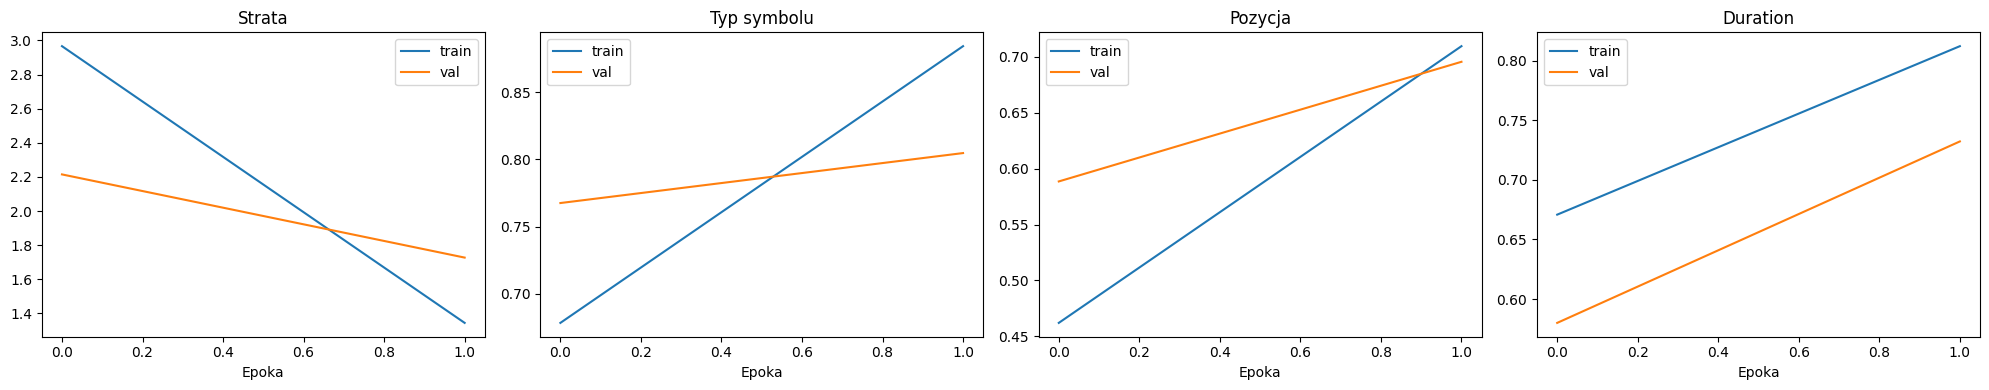

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))  
for ax, (tr, va), title in zip(axes,
    [('loss','val_loss'),('type_acc','val_type_acc'),
     ('pos_acc','val_pos_acc'),('dur_acc','val_dur_acc')],   
    ['Strata','Typ symbolu','Pozycja','Duration']):
    ax.plot(history[tr], label='train')
    ax.plot(history[va], label='val')
    ax.set_title(title); ax.legend(); ax.set_xlabel('Epoka')
plt.tight_layout(); plt.show()

## Macierze pomylek

In [11]:
def plot_cm(cm, labels, title, figsize=(13, 11), fs=7):
    fig, ax = plt.subplots(figsize=figsize)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_n = np.divide(cm.astype(float), row_sums, where=row_sums != 0)
    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=fs)
    ax.set_yticklabels(labels, fontsize=fs)
    ax.set_xlabel('Predykcja'); ax.set_ylabel('Prawdziwa klasa'); ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = cm_n[i, j]
            if v > 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=max(4, fs-2), color='white' if v > 0.5 else 'black')
    plt.tight_layout(); plt.show()


def collect_preds(loader):
    model.eval()
    tp, tt, pp, pt_, dp, dt_ = [], [], [], [], [], []
    with torch.no_grad():
        for x, tl, pl, dl in loader:
            ot, op, od = model(x.to(DEVICE))
            tp.extend(ot.argmax(1).cpu().numpy()); tt.extend(tl.numpy())

            mask_p = pl != NO_POS_LABEL
            if mask_p.sum() > 0:
                pp.extend(op.argmax(1).cpu().numpy()[mask_p.numpy()])
                pt_.extend(pl.numpy()[mask_p.numpy()])

            mask_d = dl != NO_DUR_LABEL
            if mask_d.sum() > 0:
                dp.extend(od.argmax(1).cpu().numpy()[mask_d.numpy()])
                dt_.extend(dl.numpy()[mask_d.numpy()])

    return (np.array(tp), np.array(tt),
            np.array(pp), np.array(pt_),
            np.array(dp), np.array(dt_))


type_pred, type_true, pos_pred, pos_true, dur_pred, dur_true = collect_preds(val_loader)
print(f'Type: {len(type_pred)}  Pos: {len(pos_pred)}  Dur: {len(dur_pred)}')

Type: 3600  Pos: 2141  Dur: 1774


C:\Users\bielo\AppData\Local\Temp\ipykernel_13852\605183448.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_n = np.divide(cm.astype(float), row_sums, where=row_sums != 0)


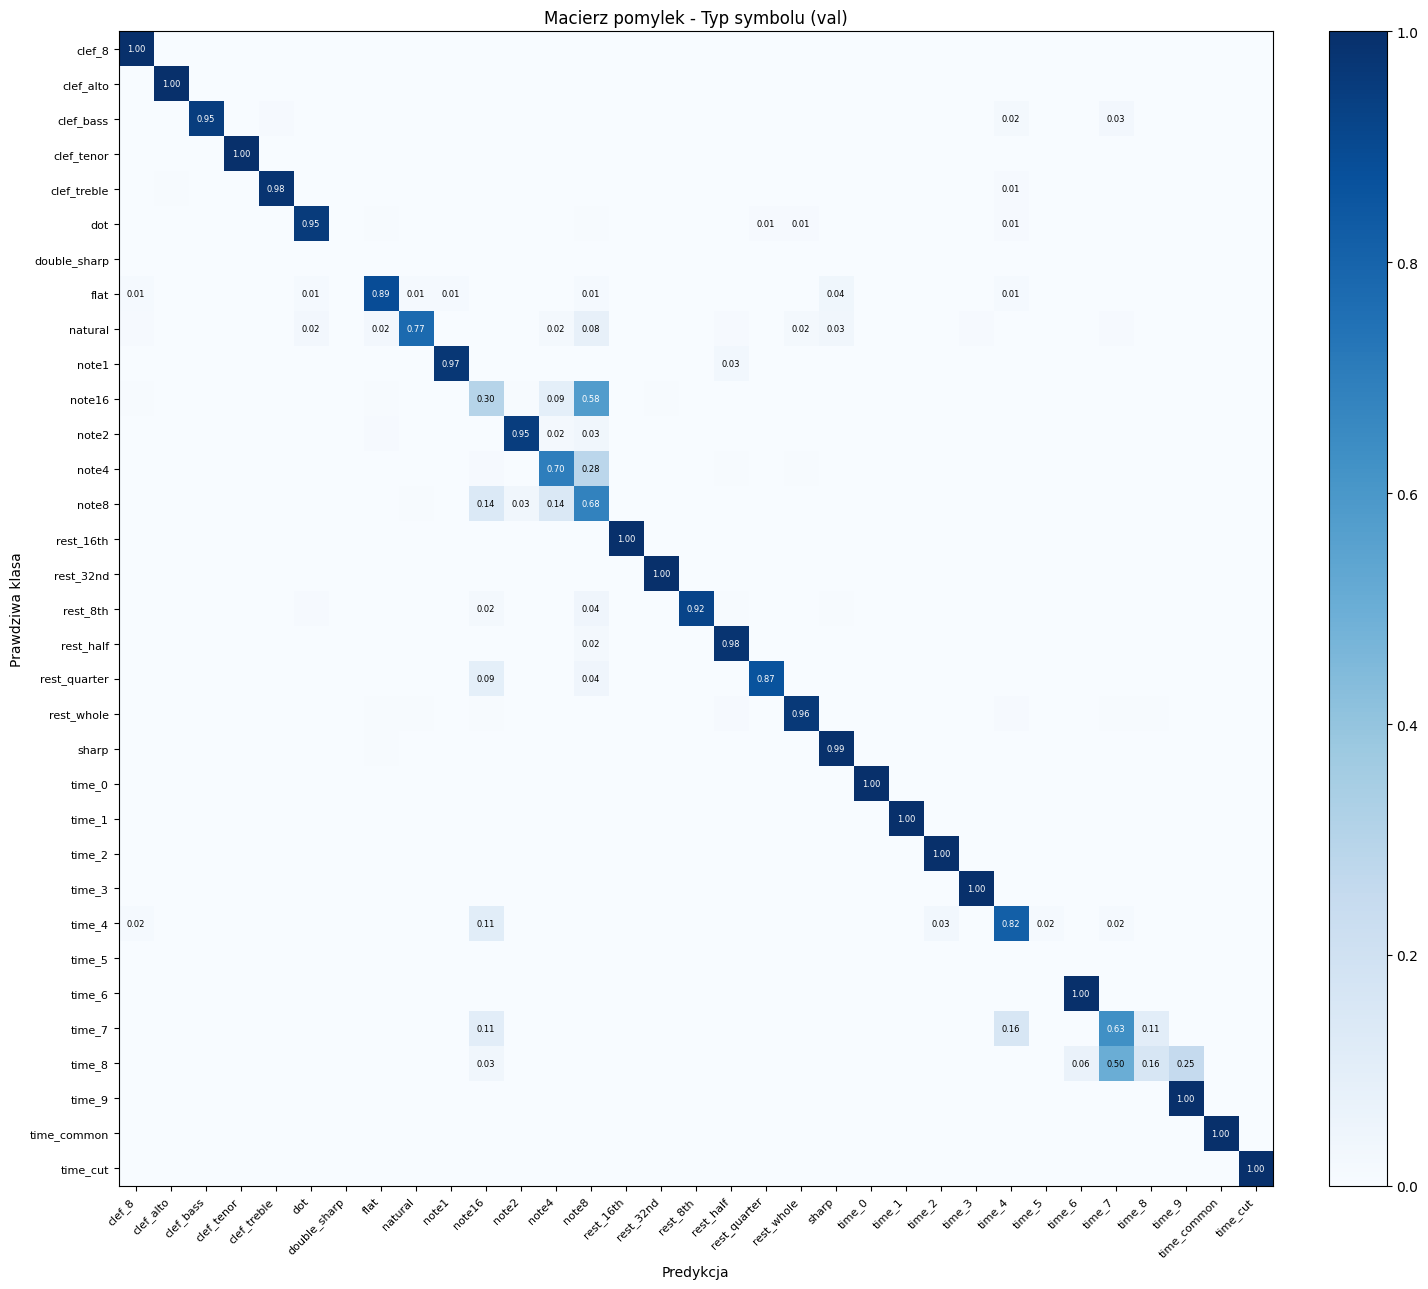

              precision    recall  f1-score   support

      clef_8       0.90      1.00      0.95        35
   clef_alto       0.95      1.00      0.97        19
   clef_bass       1.00      0.95      0.97       112
  clef_tenor       1.00      1.00      1.00        14
 clef_treble       0.99      0.98      0.99       189
         dot       0.98      0.95      0.97       284
double_sharp       0.00      0.00      0.00         0
        flat       0.89      0.89      0.89        81
     natural       0.97      0.77      0.86       124
       note1       0.97      0.97      0.97        36
      note16       0.39      0.30      0.34       130
       note2       0.95      0.95      0.95       128
       note4       0.96      0.70      0.81      1320
       note8       0.19      0.68      0.29       160
   rest_16th       1.00      1.00      1.00        26
   rest_32nd       0.67      1.00      0.80         2
    rest_8th       1.00      0.92      0.96       212
   rest_half       0.78    

In [12]:
# Macierz pomylek: TYP SYMBOLU
cm_type = confusion_matrix(type_true, type_pred, labels=list(range(NUM_TYPES)))
plot_cm(cm_type, TYPE_CLASSES, 'Macierz pomylek - Typ symbolu (val)', figsize=(15,13), fs=8)
print(classification_report(type_true, type_pred, labels=list(range(NUM_TYPES)), target_names=TYPE_CLASSES, zero_division=0))

C:\Users\bielo\AppData\Local\Temp\ipykernel_13852\605183448.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_n = np.divide(cm.astype(float), row_sums, where=row_sums != 0)


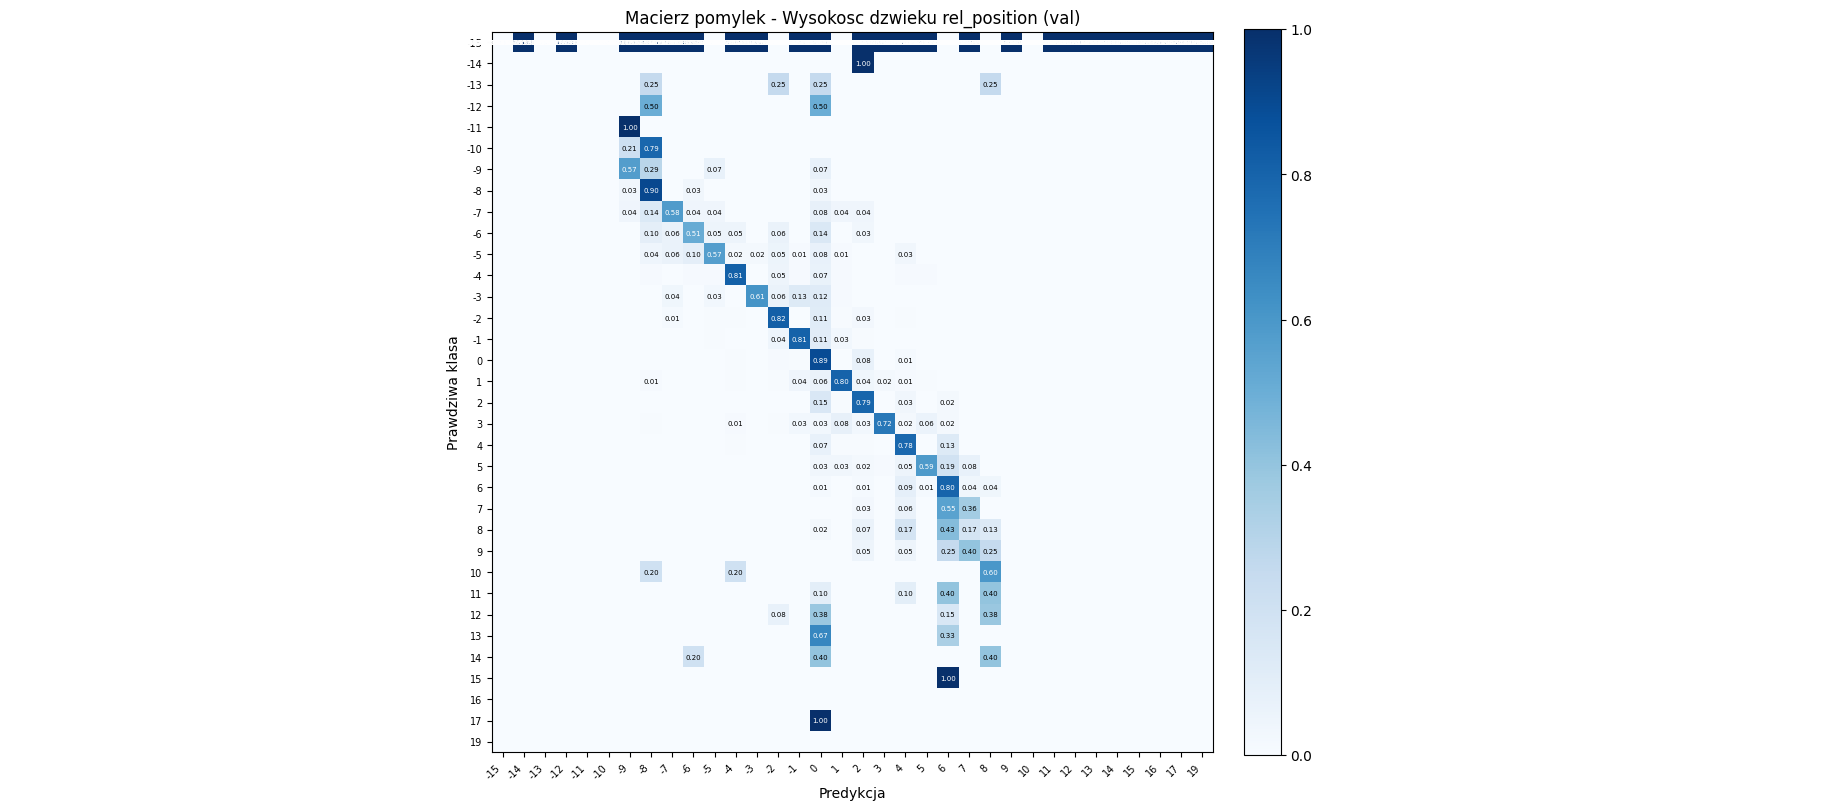

              precision    recall  f1-score   support

         -15       0.00      0.00      0.00         0
         -14       0.00      0.00      0.00         1
         -13       0.00      0.00      0.00         4
         -12       0.00      0.00      0.00         4
         -11       0.00      0.00      0.00         2
         -10       0.00      0.00      0.00        14
          -9       0.50      0.57      0.53        14
          -8       0.41      0.90      0.57        31
          -7       0.64      0.58      0.61        50
          -6       0.70      0.51      0.59        63
          -5       0.82      0.57      0.67        93
          -4       0.87      0.81      0.84       100
          -3       0.97      0.61      0.75       109
          -2       0.78      0.82      0.80       148
          -1       0.83      0.81      0.82       182
           0       0.54      0.89      0.68       211
           1       0.83      0.80      0.82       192
           2       0.77    

In [13]:
# Macierz pomylek: REL_POSITION (wysokosc dzwieku)
pos_labels = [str(p) for p in valid_pos]
cm_pos = confusion_matrix(pos_true, pos_pred, labels=list(range(NUM_POS)))
plot_cm(cm_pos, pos_labels, 'Macierz pomylek - Wysokosc dzwieku rel_position (val)',
        figsize=(17, 15), fs=7)
print(classification_report(pos_true, pos_pred, labels=list(range(NUM_POS)), target_names=pos_labels, zero_division=0))

C:\Users\bielo\AppData\Local\Temp\ipykernel_13852\605183448.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_n = np.divide(cm.astype(float), row_sums, where=row_sums != 0)


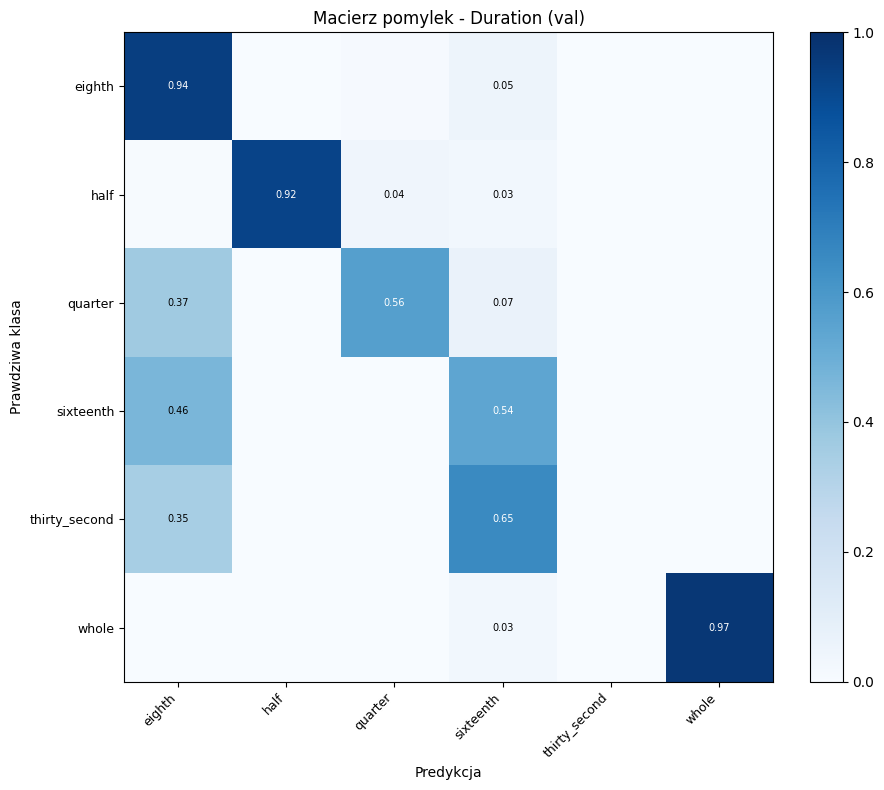

               precision    recall  f1-score   support

       eighth       0.65      0.94      0.77       721
         half       1.00      0.92      0.96       141
      quarter       0.95      0.56      0.71       408
    sixteenth       0.69      0.54      0.60       416
thirty_second       0.00      0.00      0.00        52
        whole       1.00      0.97      0.99        36

     accuracy                           0.73      1774
    macro avg       0.72      0.66      0.67      1774
 weighted avg       0.75      0.73      0.71      1774



In [14]:
dur_labels_idx  = sorted(set(dur_true) | set(dur_pred))
dur_labels_names = [DUR_CLASSES[i] for i in dur_labels_idx]

cm_dur = confusion_matrix(dur_true, dur_pred, labels=dur_labels_idx)
plot_cm(cm_dur, dur_labels_names,
        'Macierz pomylek - Duration (val)',
        figsize=(10, 8), fs=9)

print(classification_report(dur_true, dur_pred, labels=dur_labels_idx,
                             target_names=dur_labels_names, zero_division=0))

## Analiza bledow i przykladowe predykcje

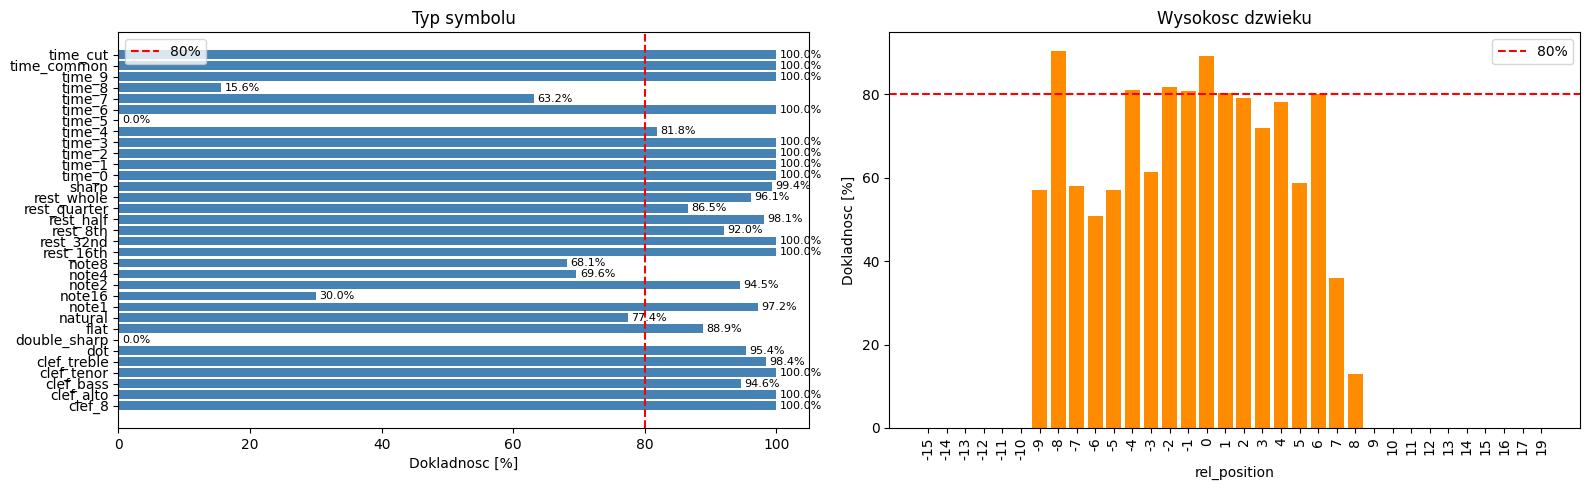


Top-10 najczestszych bledow typow:
  note4           -> note8             372x
  note16          -> note8              75x
  note8           -> note4              23x
  note8           -> note16             22x
  time_8          -> time_7             16x
  rest_quarter    -> note16             13x
  note4           -> note16             12x
  note16          -> note4              12x
  natural         -> note8              10x
  rest_8th        -> note8               9x


In [15]:
# Dokladnosc per klasa
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ta = cm_type.diagonal() / cm_type.sum(axis=1).clip(min=1)
axes[0].barh(TYPE_CLASSES, ta*100, color='steelblue')
axes[0].axvline(80, color='red', ls='--', label='80%')
axes[0].set_xlabel('Dokladnosc [%]'); axes[0].set_title('Typ symbolu'); axes[0].legend()
for i, v in enumerate(ta): axes[0].text(v*100+0.5, i, f'{v:.1%}', va='center', fontsize=8)

pa = cm_pos.diagonal() / cm_pos.sum(axis=1).clip(min=1)
axes[1].bar(pos_labels, pa*100, color='darkorange')
axes[1].axhline(80, color='red', ls='--', label='80%')
axes[1].set_xlabel('rel_position'); axes[1].set_ylabel('Dokladnosc [%]')
axes[1].set_title('Wysokosc dzwieku'); axes[1].tick_params(axis='x', rotation=90); axes[1].legend()
plt.tight_layout(); plt.show()

# Top-10 bledow typow
errors = sorted([(cm_type[i,j], TYPE_CLASSES[i], TYPE_CLASSES[j])
                 for i in range(NUM_TYPES) for j in range(NUM_TYPES) if i!=j and cm_type[i,j]>0],
                reverse=True)
print('\nTop-10 najczestszych bledow typow:')
for cnt, tl, pl in errors[:10]:
    print(f'  {tl:<15s} -> {pl:<15s}  {cnt:4d}x')

ValueError: too many values to unpack (expected 2)

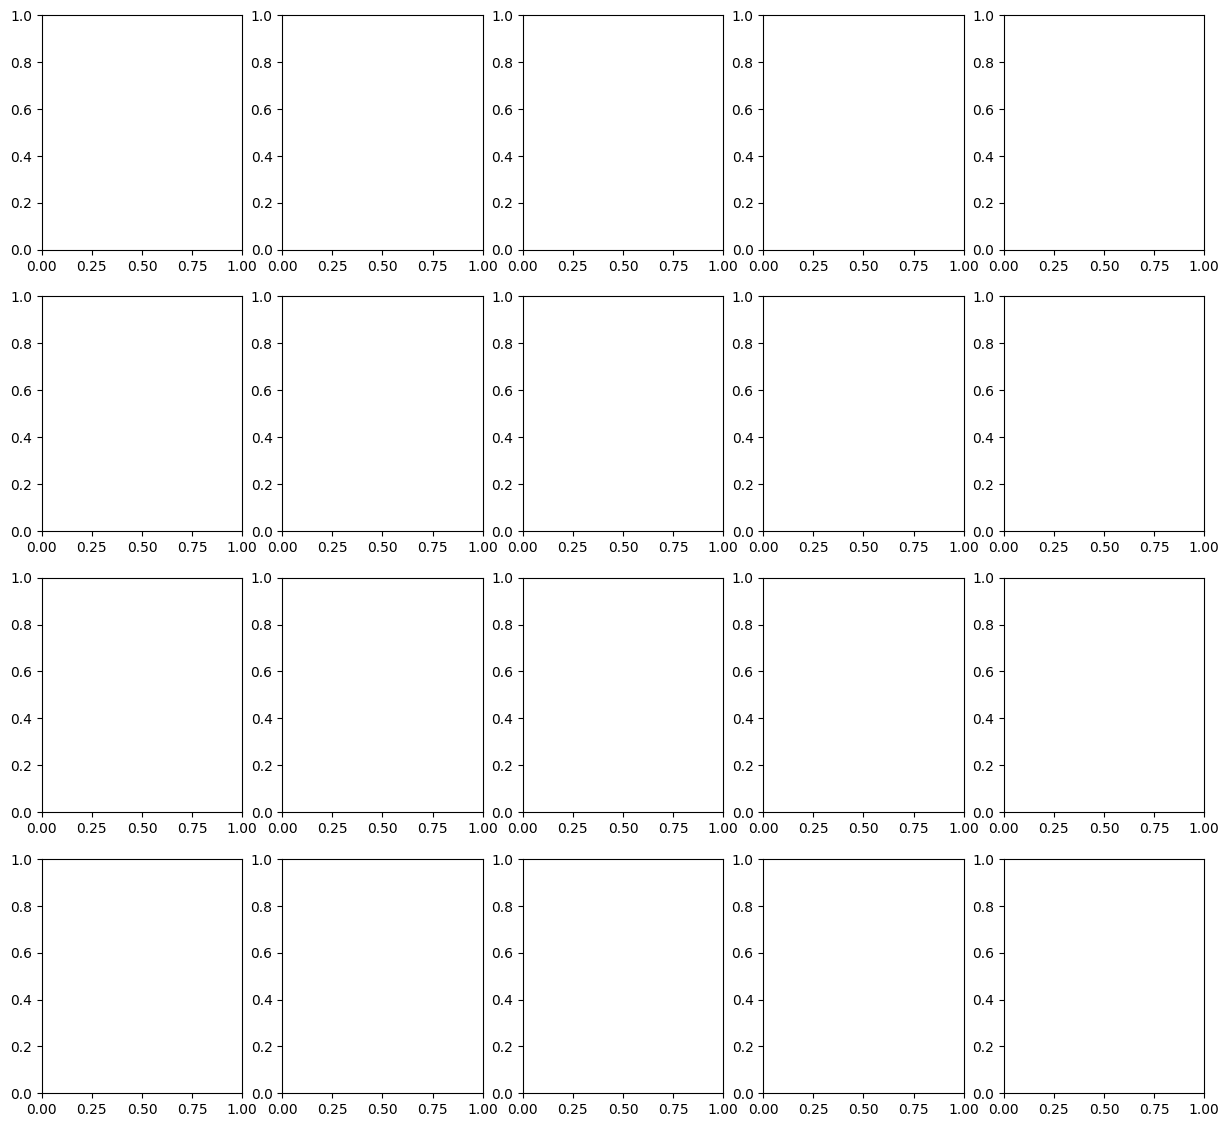

In [ ]:
def predict(img_path):
    t = preprocess(img_path)
    x = torch.tensor(t, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
            ot, op, _ = model(x)
    sym = TYPE_CLASSES[ot.argmax(1).item()]
    pos = valid_pos[op.argmax(1).item()] if sym in HAS_POSITION else None
    return sym, pos


sample = df_val.sample(20, random_state=7)
fig, axes = plt.subplots(4, 5, figsize=(15, 14))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    path = Path(row['img_dir']) / row['id']
    psym, ppos = predict(path)
    tsym = row['symbol']
    tpos = int(row['rel_position']) if pd.notna(row['rel_position']) else None
    img  = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    col = 'green' if psym == tsym else 'red'
    pos_str = f'pos: {ppos} (T:{tpos})' if tpos is not None else ''
    ax.set_title(f'P:{psym}\nT:{tsym}\n{pos_str}', fontsize=7, color=col)
    ax.axis('off')
plt.suptitle('Zielony=poprawny typ  Czerwony=bledny typ', fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
# Evaluate on test set (final unbiased evaluation)
type_pred_t, type_true_t, pos_pred_t, pos_true_t, dur_pred_t, dur_true_t = collect_preds(test_loader)
print(f'Test - Type: {len(type_pred_t)}  Pos: {len(pos_pred_t)}  Dur: {len(dur_pred_t)}')

# Type confusion & report
cm_type_t = confusion_matrix(type_true_t, type_pred_t, labels=list(range(NUM_TYPES)))
plot_cm(cm_type_t, TYPE_CLASSES, 'Macierz pomylek - Typ symbolu (test)', figsize=(15,13), fs=8)
print('Classification report - Type (test)')
print(classification_report(type_true_t, type_pred_t, labels=list(range(NUM_TYPES)), target_names=TYPE_CLASSES, zero_division=0))

# Position (rel_position)
if len(pos_true_t) > 0:
    pos_labels = [str(p) for p in valid_pos]
    cm_pos_t = confusion_matrix(pos_true_t, pos_pred_t, labels=list(range(NUM_POS)))
    plot_cm(cm_pos_t, pos_labels, 'Macierz pomylek - Wysokosc dzwieku rel_position (test)', figsize=(17,15), fs=7)
    print('Classification report - Position (test)')
    print(classification_report(pos_true_t, pos_pred_t, labels=list(range(NUM_POS)), target_names=pos_labels, zero_division=0))
else:
    print('No position-labelled samples in test set')

# Duration
if len(dur_true_t) > 0:
    dur_labels_idx  = sorted(set(dur_true_t) | set(dur_pred_t))
    dur_labels_names = [DUR_CLASSES[i] for i in dur_labels_idx]
    cm_dur_t = confusion_matrix(dur_true_t, dur_pred_t, labels=dur_labels_idx)
    plot_cm(cm_dur_t, dur_labels_names, 'Macierz pomylek - Duration (test)', figsize=(10,8), fs=9)
    print('Classification report - Duration (test)')
    print(classification_report(dur_true_t, dur_pred_t, labels=dur_labels_idx, target_names=dur_labels_names, zero_division=0))
else:
    print('No duration-labelled samples in test set')

# Save summary metrics
from sklearn.metrics import accuracy_score
metrics = {
    'type_acc': accuracy_score(type_true_t, type_pred_t) if len(type_true_t)>0 else None,
    'pos_acc': accuracy_score(pos_true_t, pos_pred_t) if len(pos_true_t)>0 else None,
    'dur_acc': accuracy_score(dur_true_t, dur_pred_t) if len(dur_true_t)>0 else None,
    'n_type': len(type_true_t), 'n_pos': len(pos_true_t), 'n_dur': len(dur_true_t)
}
import json
out_p = Path('../data/note_dataset/test_metrics.json')
out_p.parent.mkdir(parents=True, exist_ok=True)
out_p.write_text(json.dumps(metrics, indent=2))
print(f"Saved test metrics to {out_p}")